In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from sklearn.metrics import accuracy_score
import seaborn as sns

# Configuration and Seeds

In [11]:
cfg = {
    "dataset": "FashionMNIST",
    "epochs_list": [5, 10, 20],
    "batch_sizes": [32, 64, 128],
    "lr": 0.001,
    "valid_ratio": 0.1,
    "hidden_dims": [256, 128, 64],
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "random_state": 42
}

torch.manual_seed(cfg["random_state"])
np.random.seed(cfg["random_state"])
random.seed(cfg["random_state"])

print(f"Using device: {cfg['device']}")

Using device: cuda


# Load and Prepare Data


In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset_full = datasets.FashionMNIST(root="./data", train=True,
                                           download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="./data", train=False,
                                     download=True, transform=transform)

# Split train into train/validation
valid_size = int(len(train_dataset_full) * cfg["valid_ratio"])
train_size = len(train_dataset_full) - valid_size
train_dataset, valid_dataset = random_split(train_dataset_full, [train_size, valid_size])

print(f"Train: {train_size}, Valid: {valid_size}, Test: {len(test_dataset)}")


Train: 54000, Valid: 6000, Test: 10000


# Define MLP model


In [13]:
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=[256, 128, 64], output_dim=10):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.ReLU(),
            nn.Linear(hidden_dims[2], output_dim)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.layers(x)

# Training & Evaluation Functions


In [14]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            running_loss += loss.item() * X.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return running_loss / total, correct / total


# Run Experiments


In [15]:
criterion = nn.CrossEntropyLoss()
results = []

for epochs in cfg["epochs_list"]:
    for batch_size in cfg["batch_sizes"]:
        print(f"\n=== Training: epochs={epochs}, batch_size={batch_size} ===")
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_dataset, batch_size=batch_size)
        test_loader = DataLoader(test_dataset, batch_size=batch_size)

        model = MLP().to(cfg["device"])
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])

        train_losses, valid_losses, train_accs, valid_accs = [], [], [], []

        for epoch in range(epochs):
            tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, cfg["device"])
            val_loss, val_acc = evaluate(model, valid_loader, criterion, cfg["device"])
            train_losses.append(tr_loss)
            valid_losses.append(val_loss)
            train_accs.append(tr_acc)
            valid_accs.append(val_acc)
            print(f"Epoch [{epoch+1}/{epochs}] | TrainAcc: {tr_acc:.3f} | ValAcc: {val_acc:.3f}")

        test_loss, test_acc = evaluate(model, test_loader, criterion, cfg["device"])
        print(f"Test Accuracy: {test_acc:.4f}")
        results.append({
            "epochs": epochs,
            "batch_size": batch_size,
            "train_acc": train_accs[-1],
            "val_acc": valid_accs[-1],
            "test_acc": test_acc,
            "test_loss": test_loss
        })


=== Training: epochs=5, batch_size=32 ===
Epoch [1/5] | TrainAcc: 0.813 | ValAcc: 0.847
Epoch [2/5] | TrainAcc: 0.859 | ValAcc: 0.870
Epoch [3/5] | TrainAcc: 0.874 | ValAcc: 0.868
Epoch [4/5] | TrainAcc: 0.883 | ValAcc: 0.879
Epoch [5/5] | TrainAcc: 0.890 | ValAcc: 0.872
Test Accuracy: 0.8700

=== Training: epochs=5, batch_size=64 ===
Epoch [1/5] | TrainAcc: 0.811 | ValAcc: 0.854
Epoch [2/5] | TrainAcc: 0.859 | ValAcc: 0.866
Epoch [3/5] | TrainAcc: 0.874 | ValAcc: 0.869
Epoch [4/5] | TrainAcc: 0.883 | ValAcc: 0.875
Epoch [5/5] | TrainAcc: 0.891 | ValAcc: 0.868
Test Accuracy: 0.8639

=== Training: epochs=5, batch_size=128 ===
Epoch [1/5] | TrainAcc: 0.795 | ValAcc: 0.848
Epoch [2/5] | TrainAcc: 0.859 | ValAcc: 0.859
Epoch [3/5] | TrainAcc: 0.872 | ValAcc: 0.871
Epoch [4/5] | TrainAcc: 0.883 | ValAcc: 0.872
Epoch [5/5] | TrainAcc: 0.888 | ValAcc: 0.877
Test Accuracy: 0.8728

=== Training: epochs=10, batch_size=32 ===
Epoch [1/10] | TrainAcc: 0.810 | ValAcc: 0.846
Epoch [2/10] | TrainAcc

# Summary Table

In [16]:
df_results = pd.DataFrame(results)
print("\n=== Summary Results ===")
print(df_results)
df_results.style.background_gradient(cmap="Blues")


=== Summary Results ===
   epochs  batch_size  train_acc   val_acc  test_acc  test_loss
0       5          32   0.889963  0.871833    0.8700   0.382736
1       5          64   0.891259  0.867833    0.8639   0.368844
2       5         128   0.888167  0.876667    0.8728   0.359114
3      10          32   0.911074  0.882333    0.8783   0.356365
4      10          64   0.913556  0.887333    0.8824   0.353908
5      10         128   0.910741  0.885500    0.8812   0.340624
6      20          32   0.937537  0.889500    0.8822   0.404288
7      20          64   0.943833  0.888333    0.8880   0.382524
8      20         128   0.942241  0.890333    0.8846   0.364035


,epochs,batch_size,train_acc,val_acc,test_acc,test_loss
0,5,32,0.889963,0.871833,0.870000,0.382736
1,5,64,0.891259,0.867833,0.863900,0.368844
2,5,128,0.888167,0.876667,0.872800,0.359114
3,10,32,0.911074,0.882333,0.878300,0.356365
4,10,64,0.913556,0.887333,0.882400,0.353908
5,10,128,0.910741,0.885500,0.881200,0.340624
6,20,32,0.937537,0.889500,0.882200,0.404288
7,20,64,0.943833,0.888333,0.888000,0.382524
8,20,128,0.942241,0.890333,0.884600,0.364035


# Visualization: Accuracy and Loss vs Epochs (Example)

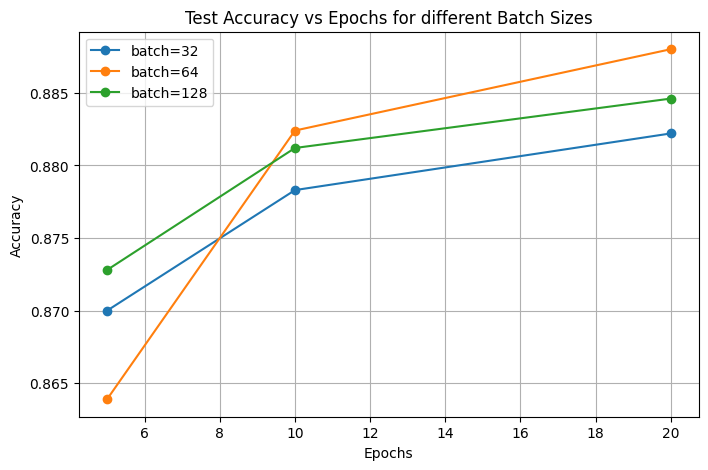

In [17]:
plt.figure(figsize=(8,5))
for bs in cfg["batch_sizes"]:
    subset = df_results[df_results["batch_size"] == bs]
    plt.plot(subset["epochs"], subset["test_acc"], marker="o", label=f"batch={bs}")
plt.title("Test Accuracy vs Epochs for different Batch Sizes")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True)
plt.show()

# Correct and Incorrect Predictions



Best config: {'epochs': 20.0, 'batch_size': 64.0, 'train_acc': 0.9438333333333333, 'val_acc': 0.8883333333333333, 'test_acc': 0.888, 'test_loss': 0.3825243155896664}


/home/ansinitro/AITU/programming-for-ai/ass4/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


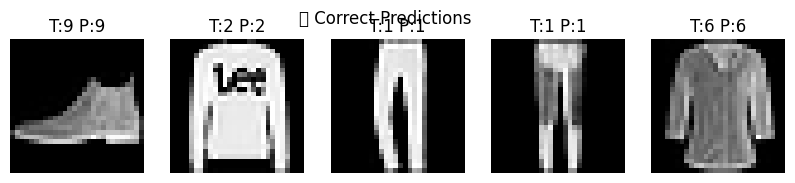

/home/ansinitro/AITU/programming-for-ai/ass4/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


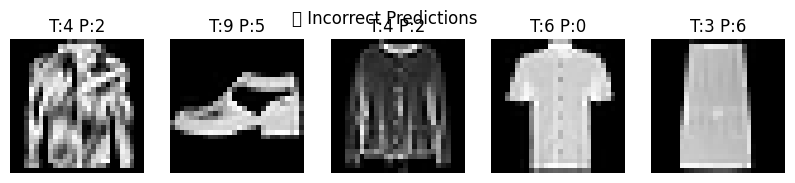

In [18]:
# Use best model (highest test accuracy)
best_cfg = df_results.loc[df_results["test_acc"].idxmax()]
print("\nBest config:", best_cfg.to_dict())

batch_size = int(best_cfg["batch_size"])
epochs = int(best_cfg["epochs"])

# Re-train best model to visualize predictions
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)
model = MLP().to(cfg["device"])
optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
for epoch in range(epochs):
    train_one_epoch(model, train_loader, optimizer, criterion, cfg["device"])

# Evaluate and get predictions
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(cfg["device"]), y.to(cfg["device"])
        outputs = model(X)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds, all_labels = np.array(all_preds), np.array(all_labels)

# Show correct and incorrect examples
correct_idx = np.where(all_preds == all_labels)[0][:5]
incorrect_idx = np.where(all_preds != all_labels)[0][:5]

def show_examples(idxs, title):
    plt.figure(figsize=(10,2))
    for i, idx in enumerate(idxs):
        img, label = test_dataset[idx]
        pred = all_preds[idx]
        plt.subplot(1,5,i+1)
        plt.imshow(img[0], cmap="gray")
        plt.title(f"T:{label} P:{pred}")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_examples(correct_idx, "✅ Correct Predictions")
show_examples(incorrect_idx, "❌ Incorrect Predictions")